to do 

1. convert kelvin to Celius
2. make new feature Diurnal Temperature Range DTR for humidity info = T2MMAX - T2MMIN

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cartopy.crs as ccrs
from preprocessing_pipline import preprocessing_pipeline, FILE_PATTERN, VARS_TO_CELSIUS, VARS_TO_CHECK

In [22]:
file_pattern = FILE_PATTERN
vars_to_convert = VARS_TO_CELSIUS
vars_to_check = VARS_TO_CHECK

In [23]:
dataset = preprocessing_pipeline(file_pattern, vars_to_convert, vars_to_check)

Loading files from: data/*.nc4.nc4


Starting data cleaning...
Checking 'T2MMAX': Found 0 missing values.
Checking 'T2MMEAN': Found 0 missing values.
Checking 'T2MMIN': Found 0 missing values.
Data cleaning complete.

Starting feature engineering...
Feature engineering complete.

Preprocessing pipeline finished successfully!


quick look at the data structure

In [ ]:
print(dataset)

<xarray.Dataset> Size: 35MB
Dimensions:     (time: 7, lat: 361, lon: 576)
Coordinates:
  * lon         (lon) float64 5kB -180.0 -179.4 -178.8 ... 178.1 178.8 179.4
  * lat         (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 89.0 89.5 90.0
  * time        (time) datetime64[ns] 56B 2024-01-01T12:00:00 ... 2024-01-07T...
Data variables:
    HOURNORAIN  (time, lat, lon) float32 6MB dask.array<chunksize=(1, 361, 576), meta=np.ndarray>
    T2MMAX      (time, lat, lon) float32 6MB dask.array<chunksize=(1, 361, 576), meta=np.ndarray>
    T2MMEAN     (time, lat, lon) float32 6MB dask.array<chunksize=(1, 361, 576), meta=np.ndarray>
    T2MMIN      (time, lat, lon) float32 6MB dask.array<chunksize=(1, 361, 576), meta=np.ndarray>
    TPRECMAX    (time, lat, lon) float32 6MB dask.array<chunksize=(1, 361, 576), meta=np.ndarray>
    TEMP_RANGE  (time, lat, lon) float32 6MB dask.array<chunksize=(1, 361, 576), meta=np.ndarray>
Attributes: (12/34)
    NCO:                               netCDF Operator

DETAILED variables and dimensions

In [25]:
dataset.info()

xarray.Dataset {
dimensions:
	time = 7 ;
	lat = 361 ;
	lon = 576 ;

variables:
	float32 HOURNORAIN(time, lat, lon) ;
		HOURNORAIN:long_name = time-during_an_hour_with_no_precipitation ;
		HOURNORAIN:units = s ;
		HOURNORAIN:fmissing_value = 999999986991104.0 ;
		HOURNORAIN:standard_name = time-during_an_hour_with_no_precipitation ;
		HOURNORAIN:cell_methods = time: sum ;
		HOURNORAIN:vmax = 999999986991104.0 ;
		HOURNORAIN:vmin = -999999986991104.0 ;
		HOURNORAIN:valid_range = [-1.e+15  1.e+15] ;
	float32 T2MMAX(time, lat, lon) ;
		T2MMAX:units = C ;
	float32 T2MMEAN(time, lat, lon) ;
		T2MMEAN:units = C ;
	float32 T2MMIN(time, lat, lon) ;
		T2MMIN:units = C ;
	float32 TPRECMAX(time, lat, lon) ;
		TPRECMAX:long_name = total_precipitation ;
		TPRECMAX:units = kg m-2 s-1 ;
		TPRECMAX:fmissing_value = 999999986991104.0 ;
		TPRECMAX:standard_name = total_precipitation ;
		TPRECMAX:cell_methods = time: maximum ;
		TPRECMAX:vmax = 999999986991104.0 ;
		TPRECMAX:vmin = -999999986991104.0 ;
		

In [ ]:
temp_var = dataset['T2MMEAN']
print(f"Mean:    {temp_var.mean().compute().item():.2f}")

range_var = dataset['TEMP_RANGE']
print(f"Mean:    {range_var.mean().compute().item():.2f}")
# this value from all around the world 

Mean:    4.22
Mean:    3.87


In [5]:
print("Data variables:", dataset.data_vars)

Data variables: Data variables:
    HOURNORAIN  (time, lat, lon) float32 6MB dask.array<chunksize=(1, 361, 576), meta=np.ndarray>
    T2MMAX      (time, lat, lon) float32 6MB dask.array<chunksize=(1, 361, 576), meta=np.ndarray>
    T2MMEAN     (time, lat, lon) float32 6MB dask.array<chunksize=(1, 361, 576), meta=np.ndarray>
    T2MMIN      (time, lat, lon) float32 6MB dask.array<chunksize=(1, 361, 576), meta=np.ndarray>
    TPRECMAX    (time, lat, lon) float32 6MB dask.array<chunksize=(1, 361, 576), meta=np.ndarray>
    TEMP_RANGE  (time, lat, lon) float32 6MB dask.array<chunksize=(1, 361, 576), meta=np.ndarray>


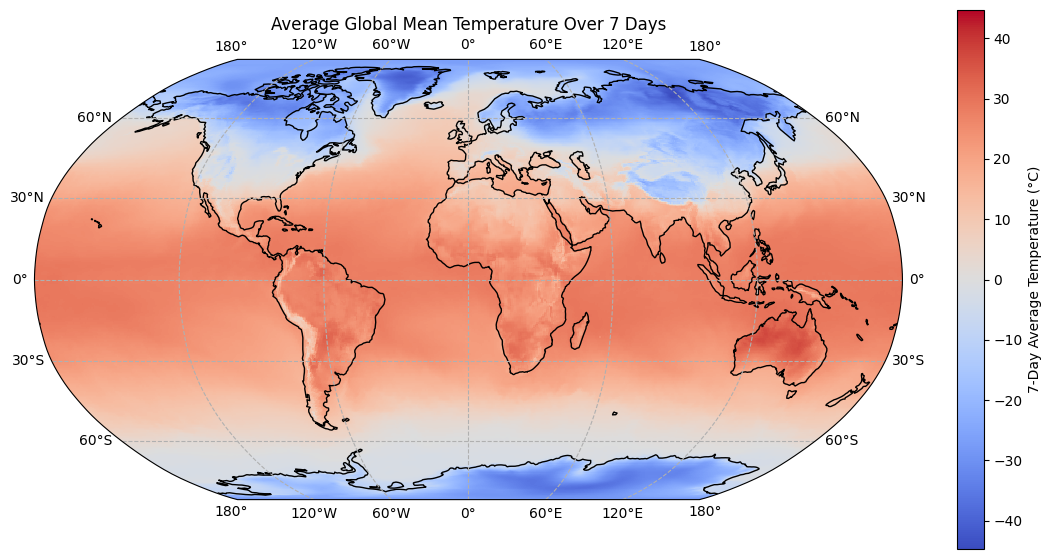

In [34]:
# Calculate the mean over the time dimension
mean_over_time = dataset['T2MMEAN'].mean(dim='time')

# Create the map
plt.figure(figsize=(14, 7))
ax = plt.axes(projection=ccrs.Robinson())

mean_over_time.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='coolwarm',
    cbar_kwargs={'label': '7-Day Average Temperature (°C)'}
)

ax.coastlines()
ax.gridlines(draw_labels=True, linestyle='--')
ax.set_title('Average Global Mean Temperature Over 7 Days')
plt.show()

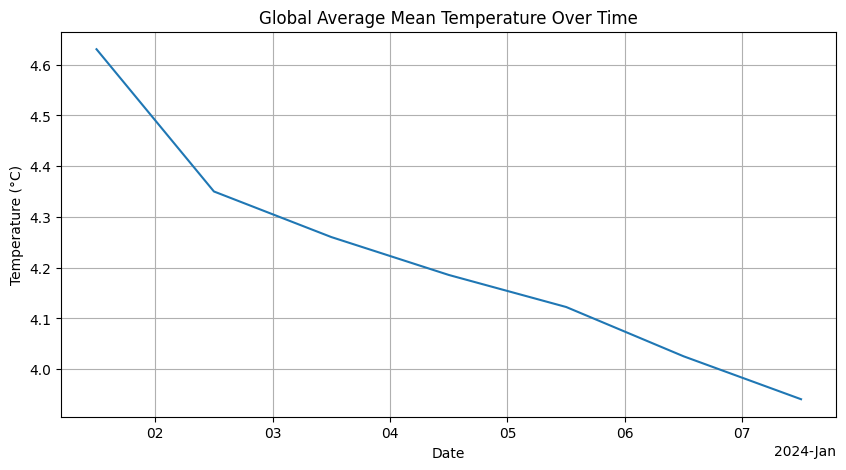

In [35]:
import matplotlib.pyplot as plt

# Calculate the global average temperature, ignoring spatial differences
global_mean_temp = dataset['T2MMEAN'].mean(dim=['lat', 'lon'])

# Plot the time series
plt.figure(figsize=(10, 5))
global_mean_temp.plot()
plt.title('Global Average Mean Temperature Over Time')
plt.ylabel('Temperature (°C)')
plt.xlabel('Date')
plt.grid(True)
plt.show()

In [40]:
import plotly.express as px
import pandas as pd

# Aggregate your data
global_mean_t2m = dataset['T2MMEAN'].mean(dim=['lat', 'lon'])
global_mean_range = dataset['TEMP_RANGE'].mean(dim=['lat', 'lon'])

# Create a pandas DataFrame for Plotly
df_agg = pd.DataFrame({
    'date': global_mean_t2m.time.values,
    'mean_temp': global_mean_t2m.values,
    'temp_range': global_mean_range.values
})

# Make the date column more readable
df_agg['date_str'] = df_agg['date'].dt.strftime('%Y-%m-%d')

# Create the interactive scatter plot
fig = px.scatter(
    df_agg,
    x='mean_temp',
    y='temp_range',
    hover_name='date_str', # This will show the date on hover
    title='Daily Global Mean Temperature vs. Temperature Range',
    labels={'mean_temp': 'Mean Temperature (°C)', 'temp_range': 'Diurnal Temperature Range (°C)'}
)

fig.update_traces(marker=dict(size=12))
fig.show()

## Variables INFO
1. HOURNORAIN =  number of hours without rain at specific long and lat
2. T2MMAX = The maximum 2-meter air temperature (where temperature is commonly measured)
3. T2MMEAN = The mean 2-meter air temperature.
4. T2MMIN = The minimum 2-meter air temperature
5. TPRECMAX =  maximum total precipitation (max number of water in all forms snow, rain..ect in a specific hour thru the day) at specific long and lat
6. TEMP_RANGE =  Diurnal Temperature Range (DTR) provide humditiy info

Low DTR = High Humidity: cloud cover, and evaporating large body of water.
High DTR = Low Humidity: dry air, clear skies, and an inland or desert location

it can help with the training for the average temp since it will help the model understand what climate type its dealing with, for example egypt will have high DTR but in places like ALEX it will have low DTR

DTR values: 
1. less than 8°C (14°F) likely mean in tropical, coastal, and very humid regions
2. Between 8°C and 12°C (14°F - 22°F) likely mean inland, temperate climates
3. greater than 12°C (22°F) mean drier, clearer, and often continental or desert climate.
4. exceed 20°C (36°F) in hot, dry deserts.


tip for ML: instead of giving the model T2MMAX and T2MMIN as input features we can drop them and give the model only the location (long lat) so it can identify temp trends in these locations

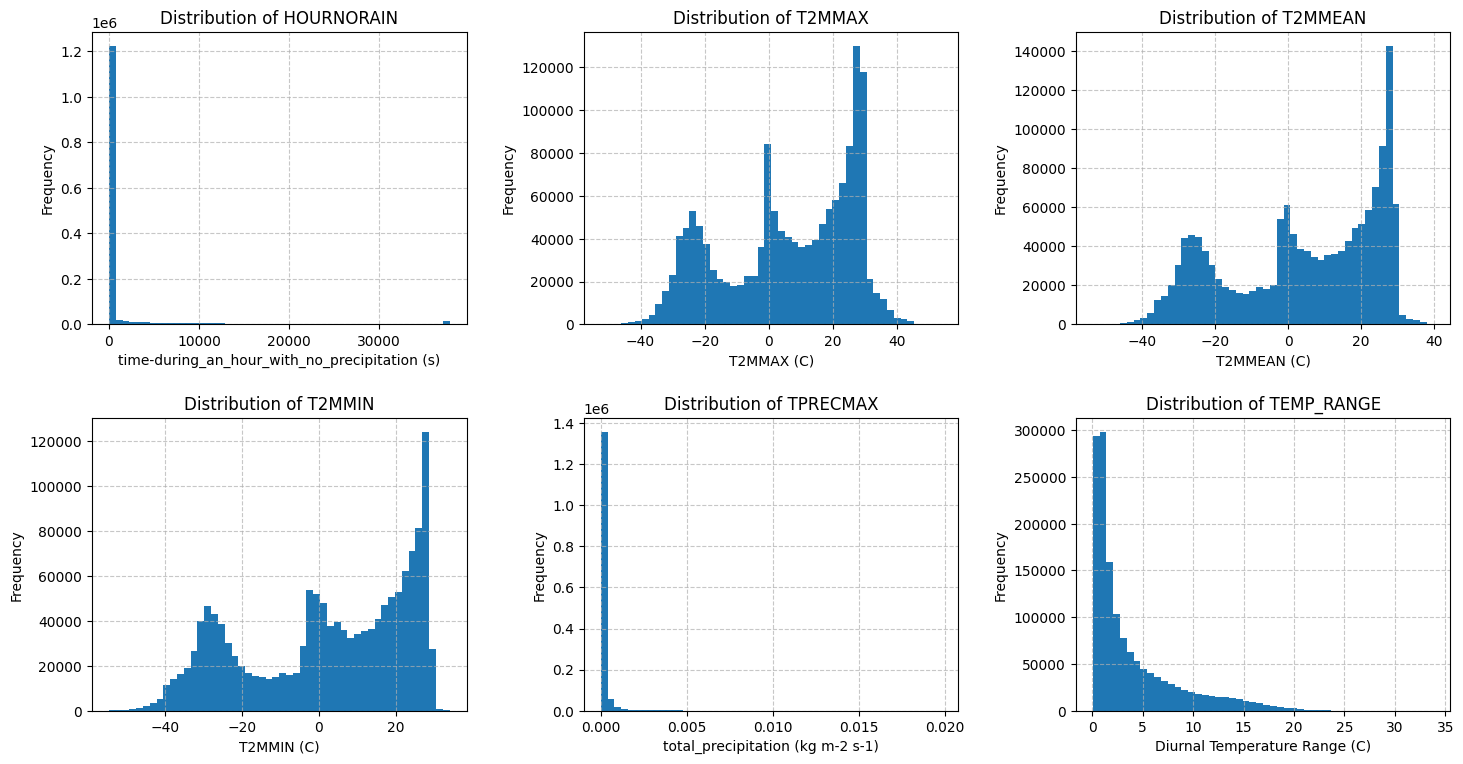

In [49]:
variables_to_plot = list(dataset.data_vars)

# Determine the grid size for the subplots (e.g., 3 columns)
num_vars = len(variables_to_plot)
num_cols = 3
num_rows = int(np.ceil(num_vars / num_cols))

# Create a figure with a grid of subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, num_rows * 4))

# Flatten the axes array so we can easily loop through it
axes = axes.flatten()

# Loop through each variable and its corresponding subplot axis
for i, var_name in enumerate(variables_to_plot):
    ax = axes[i]
    data_array = dataset[var_name]
    
    # Plot the histogram on the current subplot axis
    data_array.plot.hist(ax=ax, bins=50)
    
    # Set a descriptive title and labels for the subplot
    ax.set_title(f'Distribution of {var_name}')
    ax.set_xlabel(f"{data_array.attrs.get('long_name', var_name)} ({data_array.attrs.get('units', 'N/A')})")
    ax.set_ylabel('Frequency')
    ax.grid(True, linestyle='--', alpha=0.7)

# Hide any unused subplots
for j in range(num_vars, len(axes)):
    axes[j].set_visible(False)

# Adjust the layout to make sure titles and labels don't overlap
plt.tight_layout(pad=2.0)
plt.show()


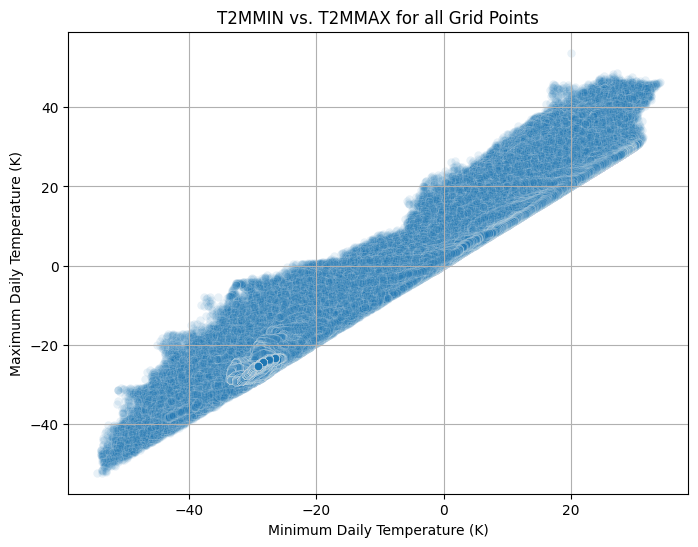

In [42]:
# Flatten the 2D arrays for T2MMIN and T2MMAX into 1D lists of values
min_temps_flat = dataset['T2MMIN'].values.flatten()
max_temps_flat = dataset['T2MMAX'].values.flatten()

# Create a scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=min_temps_flat, y=max_temps_flat, alpha=0.1) # alpha for transparency
plt.title('T2MMIN vs. T2MMAX for all Grid Points')
plt.xlabel('Minimum Daily Temperature (K)')
plt.ylabel('Maximum Daily Temperature (K)')
plt.grid(True)
plt.show()

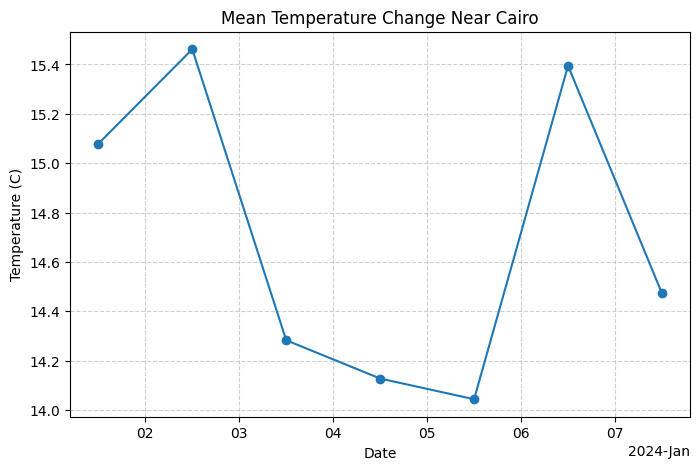

In [45]:
ds_combined = dataset.load()
cairo_ts = ds_combined['T2MMEAN'].sel(lat=30.0, lon=31.2, method='nearest')


plt.figure(figsize=(8, 5))
cairo_ts.plot(marker='o', linestyle='-')
plt.title('Mean Temperature Change Near Cairo')
plt.ylabel('Temperature (C)')
plt.xlabel('Date')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

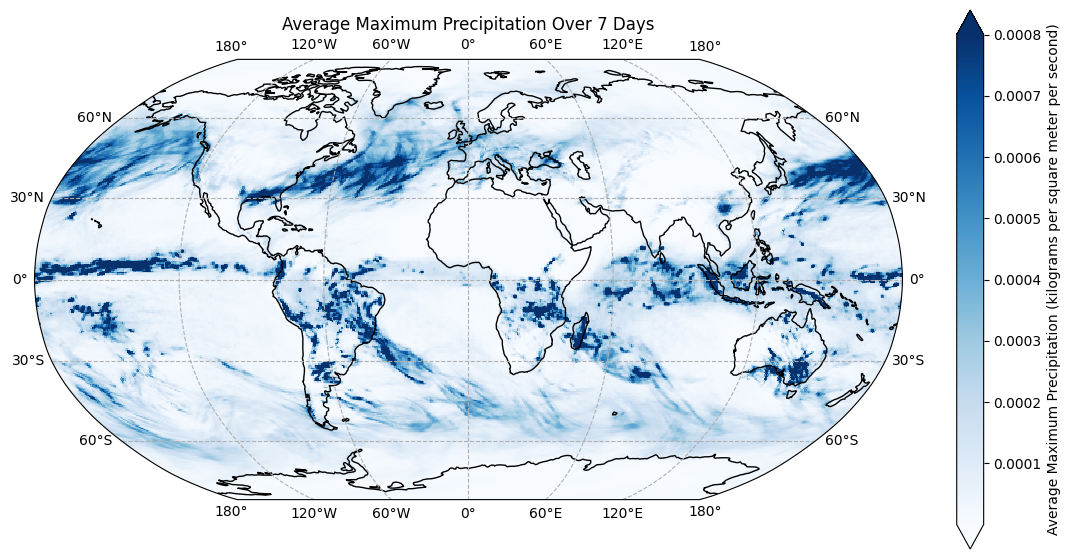

In [48]:
# Calculate the mean of TPRECMAX across the time dimension
mean_precip = dataset['TPRECMAX'].mean(dim='time')

# Create the map
plt.figure(figsize=(14, 7))
ax = plt.axes(projection=ccrs.Robinson())

mean_precip.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='Blues',
    robust=True, # Handle outliers for a better color range
    cbar_kwargs={'label': 'Average Maximum Precipitation (kilograms per square meter per second)'}
)

ax.coastlines()
ax.gridlines(draw_labels=True, linestyle='--')
ax.set_title('Average Maximum Precipitation Over 7 Days')
plt.show()